# PD detection — data preparation v2 and Test 3 in one notebook

This notebook combines the v2 data preparation (pulse features, Kaggle test set) and Test 3 (ensembles, LightGBM, blending, Kaggle submission files).

**It avoids redoing the slow preprocessing on every run.** Part A (preprocessing, 1–2 hours) only runs when no processed files are available. After the first full commit, attach this notebook's own committed output as an input (**Add Input > Your Work**, select this notebook). On later runs, Part A then loads the saved files in seconds and goes straight to training.

**Inputs:**
- First run: the competition data (`vsb-power-line-fault-detection`).
- Later runs: this notebook's previous committed output (the competition data can stay attached; it's only read if processing is needed).

**Settings to check before running:**
- `LIMIT = 60` runs a quick preprocessing test only; training is skipped automatically, because 60 signals are too few to train on. Set `LIMIT = None` for the real run.
- Switch on the **GPU** for the real run. The first full commit takes roughly 1.5–3 hours (preprocessing plus training) and counts against your weekly GPU hours; later runs that reuse the saved files take about 20–40 minutes.

## 1. Settings

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'      # needed for deterministic GPU results

import glob, json, random, time, warnings
warnings.filterwarnings('ignore', message='.*eval_set.*')   # harmless LightGBM notice in newer versions
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import pywt
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import lightgbm as lgb

OUT_DIR = '/kaggle/working'
LIMIT = None                 # quick test (preprocessing only); set to None for the real run
FORCE_PREP = False         # True = always reprocess, even if processed files are attached

# ---- Part A: preprocessing settings (unchanged from v2) ----
N_SAMPLES = 800_000
DURATION = 0.02
FS = N_SAMPLES / DURATION          # 40 MHz
HIGHPASS_CUTOFF = 10_000           # Hz
N_CHUNKS = 160
CHUNK_LEN = N_SAMPLES // N_CHUNKS  # 5,000 samples per chunk
SPLIT_SEED = 42
PEAK_LOW = 5                       # pulse threshold, in multiples of the noise level
PEAK_HIGH = 8                      # stricter threshold for strong pulses
MIN_PEAK_DISTANCE = 20             # samples (0.5 microseconds)
FEATURE_NAMES = ['mean', 'std', 'min', 'max', 'range', 'p1', 'p99',
                 'pulses_5sd', 'pulses_8sd', 'pos_pulses_5sd', 'neg_pulses_5sd', 'pulse_strength_sum']
N_FEATURES = len(FEATURE_NAMES)

# ---- Part B: training settings (unchanged from Test 3) ----
SEEDS = [42, 7, 2026]
N_FOLDS = 5
BATCH_SIZE = 64
MAX_EPOCHS = 80
PATIENCE = 20
os.makedirs(f'{OUT_DIR}/models', exist_ok=True)

torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device, '| PyTorch', torch.__version__, '| LightGBM', lgb.__version__)

Using device: cuda | PyTorch 2.11.0+cu128 | LightGBM 4.6.0


# Part A — Data preparation

## 2. Find the data and decide whether to preprocess

The notebook looks for processed files (`X_train_v2.npy`) among the attached inputs. If full-size files (all 8,712 signals) are found, `LIMIT` is None and `FORCE_PREP` is False, it loads them instead of preprocessing. Quick-test files are ignored automatically. Otherwise it locates the raw competition data and preprocesses.

In [2]:
saved = glob.glob('/kaggle/input/**/X_train_v2.npy', recursive=True)
saved_full = bool(saved) and np.load(saved[0], mmap_mode='r').shape[0] == 8712   # ignore quick-test outputs
if saved and not saved_full:
    print('Attached processed files are from a quick test (not all 8,712 signals), so they will be ignored.')
DO_PREP = FORCE_PREP or LIMIT is not None or not saved_full

if DO_PREP:
    raw_meta = glob.glob('/kaggle/input/**/metadata_train.csv', recursive=True)
    assert raw_meta, 'Competition data not found: Add Input > Competition Datasets > vsb-power-line-fault-detection'
    DATA_DIR = raw_meta[0].rsplit('/', 1)[0]
    print('Preprocessing from raw data in', DATA_DIR)
else:
    PREP_DIR = saved[0].rsplit('/', 1)[0]
    print('Processed files found: loading from', PREP_DIR, '(preprocessing skipped)')

Preprocessing from raw data in /kaggle/input/competitions/vsb-power-line-fault-detection


## 3. Preprocessing functions

Identical to the v2 preparation notebook:
- **High-pass filter:** 5th-order zero-phase Butterworth at 10 kHz removes the 50 Hz grid wave.
- **Wavelet denoising:** level-1 `db4`, universal hard threshold.
- **Seven basic features per chunk:** mean, standard deviation, minimum, maximum, range, 1st and 99th percentiles.
- **Five pulse features per chunk:** pulses ≥5σ, pulses ≥8σ, positive and negative pulses ≥5σ, and the sum of pulse heights. σ is each signal's own noise level, so thresholds are fair between quiet and noisy signals.

In [3]:
SOS = signal.butter(5, HIGHPASS_CUTOFF, btype='highpass', fs=FS, output='sos')

def highpass(x):
    return signal.sosfiltfilt(SOS, x)

def wavelet_denoise(x, wavelet='db4', level=1):
    coeffs = pywt.wavedec(x, wavelet, mode='per', level=level)
    sigma = np.median(np.abs(coeffs[-1] - np.median(coeffs[-1]))) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(len(x)))
    coeffs[1:] = [pywt.threshold(c, value=threshold, mode='hard') for c in coeffs[1:]]
    return pywt.waverec(coeffs, wavelet, mode='per')[:len(x)]

def basic_features(x):
    chunks = x.reshape(N_CHUNKS, -1)
    return np.stack([chunks.mean(1), chunks.std(1), chunks.min(1), chunks.max(1),
                     chunks.max(1) - chunks.min(1),
                     np.percentile(chunks, 1, axis=1), np.percentile(chunks, 99, axis=1)], axis=1)

def find_pulses(x):
    sigma = np.median(np.abs(x - np.median(x))) / 0.6745 + 1e-9
    z = x / sigma
    peaks, props = signal.find_peaks(np.abs(z), height=PEAK_LOW, distance=MIN_PEAK_DISTANCE)
    return peaks, props['peak_heights'], np.sign(z[peaks]), sigma

def pulse_features(x):
    peaks, heights, signs, _ = find_pulses(x)
    chunk = peaks // CHUNK_LEN
    count = lambda mask: np.bincount(chunk[mask], minlength=N_CHUNKS)
    return np.stack([count(np.ones(len(peaks), bool)), count(heights >= PEAK_HIGH),
                     count(signs > 0), count(signs < 0),
                     np.bincount(chunk, weights=heights, minlength=N_CHUNKS)], axis=1)

def preprocess(raw):
    x = wavelet_denoise(highpass(raw.astype(np.float32)))
    return np.concatenate([basic_features(x), pulse_features(x)], axis=1).astype(np.float32)   # (160, 12)

def process(parquet_file, ids):
    X = np.zeros((len(ids), N_CHUNKS, N_FEATURES), dtype=np.float32)
    for start in tqdm(range(0, len(ids), 300), desc=parquet_file):
        batch = ids[start:start + 300]
        table = pq.read_table(f'{DATA_DIR}/{parquet_file}', columns=[str(s) for s in batch])
        for j, s in enumerate(batch):
            X[start + j] = preprocess(table.column(str(s)).to_numpy())
        del table
    return X

## 4. Preprocess (or load) and save

When preprocessing, the v1 split is reproduced exactly (same code and seed), both datasets are processed, and five files are saved to the output. The visual check plots detected pulses on the first PD signal: orange marks pulses of 5–8σ, red marks pulses of at least 8σ.

When loading, the saved files are read in seconds.

       count  pd_share
split                 
test    1308  0.055810
train   6096  0.061188
val     1308  0.060398


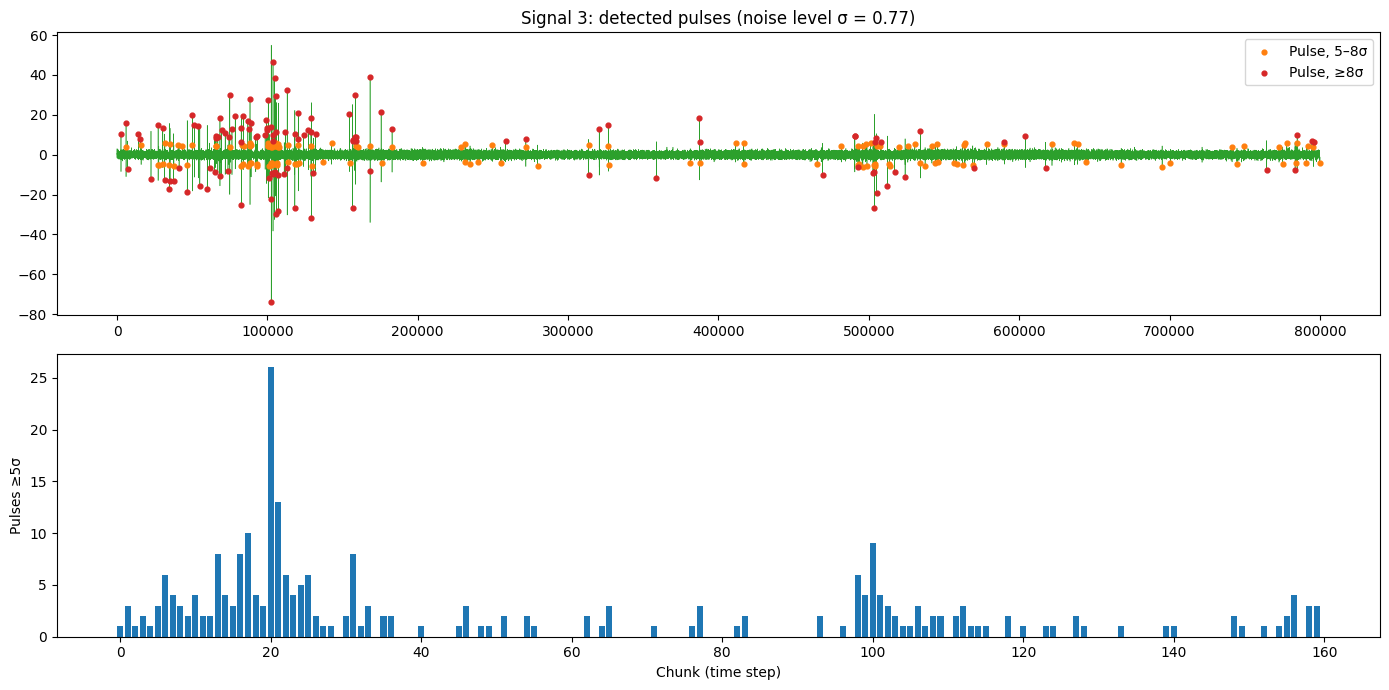

train.parquet:   0%|          | 0/30 [00:00<?, ?it/s]

test.parquet:   0%|          | 0/68 [00:00<?, ?it/s]

Processed and saved.
Labelled: (8712, 160, 12) | Kaggle test: (20337, 160, 12)


In [4]:
if DO_PREP:
    meta = pd.read_csv(f'{DATA_DIR}/metadata_train.csv')
    meta_k = pd.read_csv(f'{DATA_DIR}/metadata_test.csv')
    meas = meta.groupby('id_measurement')['target'].max().reset_index()
    train_ids, temp_ids = train_test_split(meas['id_measurement'], test_size=0.30,
                                           stratify=meas['target'], random_state=SPLIT_SEED)
    temp = meas[meas['id_measurement'].isin(temp_ids)]
    val_ids, test_ids = train_test_split(temp['id_measurement'], test_size=0.50,
                                         stratify=temp['target'], random_state=SPLIT_SEED)
    split_map = {**{m: 'train' for m in train_ids}, **{m: 'val' for m in val_ids}, **{m: 'test' for m in test_ids}}
    meta['split'] = meta['id_measurement'].map(split_map)
    assert meta['split'].notna().all()
    print(meta.groupby('split')['target'].agg(count='count', pd_share='mean'))

    # Visual check on one PD signal
    sid = meta.loc[meta['target'] == 1, 'signal_id'].iloc[0]
    raw = pq.read_table(f'{DATA_DIR}/train.parquet', columns=[str(sid)]).column(0).to_numpy()
    x = wavelet_denoise(highpass(raw.astype(np.float32)))
    peaks, heights, signs, sigma = find_pulses(x)
    strong = heights >= PEAK_HIGH
    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    axes[0].plot(x, linewidth=0.4, color='tab:green')
    axes[0].scatter(peaks[~strong], x[peaks[~strong]], s=12, color='tab:orange', label='Pulse, 5–8σ', zorder=3)
    axes[0].scatter(peaks[strong], x[peaks[strong]], s=12, color='tab:red', label='Pulse, ≥8σ', zorder=3)
    axes[0].set_title(f'Signal {sid}: detected pulses (noise level σ = {sigma:.2f})'); axes[0].legend()
    axes[1].bar(np.arange(N_CHUNKS), pulse_features(x)[:, 0], color='tab:blue')
    axes[1].set_xlabel('Chunk (time step)'); axes[1].set_ylabel('Pulses ≥5σ')
    plt.tight_layout(); plt.show()

    if LIMIT:
        meta, meta_k = meta.iloc[:LIMIT], meta_k.iloc[:LIMIT]
    X_raw = process('train.parquet', meta['signal_id'].values)
    XK_raw = process('test.parquet', meta_k['signal_id'].values)
    np.save(f'{OUT_DIR}/X_train_v2.npy', X_raw); meta.to_csv(f'{OUT_DIR}/meta_train_v2.csv', index=False)
    np.save(f'{OUT_DIR}/X_kaggle_test_v2.npy', XK_raw); meta_k.to_csv(f'{OUT_DIR}/meta_kaggle_test.csv', index=False)
    with open(f'{OUT_DIR}/feature_names.json', 'w') as f:
        json.dump(FEATURE_NAMES, f)
    print('Processed and saved.')
else:
    X_raw = np.load(f'{PREP_DIR}/X_train_v2.npy')
    XK_raw = np.load(f'{PREP_DIR}/X_kaggle_test_v2.npy')
    meta = pd.read_csv(f'{PREP_DIR}/meta_train_v2.csv')
    meta_k = pd.read_csv(f'{PREP_DIR}/meta_kaggle_test.csv')
    assert json.load(open(f'{PREP_DIR}/feature_names.json')) == FEATURE_NAMES, 'saved features differ from current settings'

print('Labelled:', X_raw.shape, '| Kaggle test:', XK_raw.shape)

## 5. Quick check: do the pulse features separate PD from normal signals?

In [5]:
y = meta['target'].values
total_pulses = X_raw[:, :, FEATURE_NAMES.index('pulses_5sd')].sum(axis=1)
strong_pulses = X_raw[:, :, FEATURE_NAMES.index('pulses_8sd')].sum(axis=1)
for label, name in [(1, 'PD'), (0, 'Normal')]:
    print(f'{name:6s} signals: average {total_pulses[y == label].mean():7.1f} pulses ≥5σ, '
          f'{strong_pulses[y == label].mean():6.1f} pulses ≥8σ')

PD     signals: average  1016.8 pulses ≥5σ,  545.2 pulses ≥8σ
Normal signals: average   330.1 pulses ≥5σ,  111.7 pulses ≥8σ


# Part B — Test 3: training, comparison and Kaggle submission

**What it compares** (all with three-phase input and the regularised model from Test 2):

| Experiment | What it is | What it shows |
|---|---|---|
| `CNN_7feat` | 1D-CNN on the original 7 features | Baseline for this test |
| `CNN_12feat` | 1D-CNN on all 12 features | Effect of the pulse features |
| `LGBM_12feat` | LightGBM on summary features | A boosted-tree model, like the top Kaggle solutions |
| `Blend` | Average of `CNN_12feat` and `LGBM_12feat` | Whether combining both beats either one |

Each is repeated with 3 seeds × 5 folds (15 models), with deterministic mode and early-stopping patience 20. The internal test set stays unused.

## 6. Data check and three-phase inputs

The first line stops the notebook with a clear message if only the quick-test data is available, since 60 signals are too few to train on (some folds would contain no PD signals at all).

Pulse counts are compressed with `log1p` for the neural network. Each signal gets its own phase's features first, then the other two phases: 21 channels with 7 features, 36 with 12.

In [6]:
assert len(X_raw) == 8712 and len(XK_raw) == 20337, \
    f'Only quick-test data available {X_raw.shape}: set LIMIT = None and run again to train'

PULSE_COLS = list(range(7, 12))
def nn_ready(X):
    X = X.copy(); X[:, :, PULSE_COLS] = np.log1p(X[:, :, PULSE_COLS]); return X

groups = meta['id_measurement'].values
pool_idx = np.where(meta['split'].isin(['train', 'val']))[0]
test_idx = np.where(meta['split'] == 'test')[0]

def phase_order(m):
    pos = {(a, b): i for i, (a, b) in enumerate(zip(m['id_measurement'], m['phase']))}
    assert all((a, q) in pos for a in m['id_measurement'].unique() for q in range(3)), 'missing phase'
    return np.array([[pos[(a, (b + k) % 3)] for k in range(3)] for a, b in zip(m['id_measurement'], m['phase'])])

ORDER, ORDER_K = phase_order(meta), phase_order(meta_k)

def three_phase(X, order, cols):
    return np.concatenate([X[order[:, k]][:, :, cols] for k in range(3)], axis=2)

Xn, XKn = nn_ready(X_raw), nn_ready(XK_raw)
INPUTS = {
    '7feat':  (three_phase(Xn, ORDER, list(range(7))), three_phase(XKn, ORDER_K, list(range(7)))),
    '12feat': (three_phase(Xn, ORDER, list(range(12))), three_phase(XKn, ORDER_K, list(range(12)))),
}
for k, (a, b) in INPUTS.items():
    print(f'{k}: labelled {a.shape}, Kaggle test {b.shape}')
print(f'Pool: {len(pool_idx)} signals ({y[pool_idx].sum()} PD) | internal test (unused): {len(test_idx)}')

7feat: labelled (8712, 160, 21), Kaggle test (20337, 160, 21)
12feat: labelled (8712, 160, 36), Kaggle test (20337, 160, 36)
Pool: 7404 signals (452 PD) | internal test (unused): 1308


## 7. Summary features for the tree model

One row per signal. For each of its three phases (own phase first), 25 numbers: totals of the 5 pulse features, pulses ≥5σ and ≥8σ in each 45° window of the cycle, and the average and maximum activity and spike range. 3 × 25 = 75 numbers per signal.

In [7]:
def phase_table(X):
    n = len(X)
    tot = X[:, :, 7:12].sum(axis=1)
    bins5 = X[:, :, 7].reshape(n, 8, 20).sum(axis=2)
    bins8 = X[:, :, 8].reshape(n, 8, 20).sum(axis=2)
    std, rng = X[:, :, 1], X[:, :, 4]
    stats = np.stack([std.mean(1), std.max(1), rng.max(1), np.percentile(rng, 90, axis=1)], axis=1)
    return np.concatenate([tot, bins5, bins8, stats], axis=1)

base_names = ([f'total_{f}' for f in FEATURE_NAMES[7:12]] + [f'pulses5_{i * 45}deg' for i in range(8)] +
              [f'pulses8_{i * 45}deg' for i in range(8)] + ['std_mean', 'std_max', 'range_max', 'range_p90'])
TAB_NAMES = [f'{p}_{n}' for p in ['own', 'next', 'other'] for n in base_names]

def table(X, order):
    T = phase_table(X)
    return np.concatenate([T[order[:, k]] for k in range(3)], axis=1)

TAB, TAB_K = table(X_raw, ORDER), table(XK_raw, ORDER_K)
print('Tree-model features:', TAB.shape, '| Kaggle test:', TAB_K.shape)

Tree-model features: (8712, 75) | Kaggle test: (20337, 75)


## 8. Models and training functions

- `PDNetSmall`: set-up C from Test 2 (regularised 1D-CNN), with 21 or 36 input channels.
- `train_cnn`: per-fold normalisation, class-weighted loss, Adam (weight decay 1e-3), learning-rate schedule, early stopping on validation MCC (patience 20). Also predicts the internal test set and the Kaggle test set.
- `train_lgbm`: LightGBM with class weighting (`scale_pos_weight`) and early stopping after 100 rounds without improvement.

In [8]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def conv_block(c_in, c_out, k):
    return nn.Sequential(nn.Conv1d(c_in, c_out, k, padding=k // 2), nn.BatchNorm1d(c_out), nn.ReLU(), nn.MaxPool1d(2))

class PDNetSmall(nn.Module):
    def __init__(self, in_channels, seq_len=160):
        super().__init__()
        self.features = nn.Sequential(conv_block(in_channels, 32, 5), conv_block(32, 64, 5), conv_block(64, 64, 3),
                                      nn.Conv1d(64, 16, 1), nn.BatchNorm1d(16), nn.ReLU())
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.5), nn.Linear(16 * (seq_len // 8), 32),
                                        nn.ReLU(), nn.Dropout(0.5), nn.Linear(32, 1))
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)

class PDDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)
        self.y = torch.tensor(np.zeros(len(X)) if y is None else y, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def predict(model, X):
    model.eval(); out = []
    with torch.no_grad():
        for xb, _ in DataLoader(PDDataset(X), batch_size=512):
            out.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
    return np.concatenate(out)

def train_cnn(X, XK, tr, va, seed, tag):
    mean = X[tr].mean(axis=(0, 1)); std = X[tr].std(axis=(0, 1)) + 1e-6
    norm = lambda a: (a - mean) / std
    set_seed(seed)
    model = PDNetSmall(X.shape[2]).to(device)
    pos_weight = torch.tensor([(len(tr) - y[tr].sum()) / y[tr].sum()], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)
    g = torch.Generator(); g.manual_seed(seed)
    loader = DataLoader(PDDataset(norm(X[tr]), y[tr]), batch_size=BATCH_SIZE, shuffle=True, generator=g)
    X_va = norm(X[va])
    best, best_state, best_epoch, waited = -1.0, None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(); loss = criterion(model(xb), yb); loss.backward(); optimizer.step()
        mcc = matthews_corrcoef(y[va], predict(model, X_va) > 0.5)
        scheduler.step(mcc)
        if mcc > best:
            best, best_epoch, waited = mcc, epoch, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            waited += 1
            if waited >= PATIENCE:
                break
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), f'{OUT_DIR}/models/{tag}.pt')
    return predict(model, X_va), predict(model, norm(X[test_idx])), predict(model, norm(XK)), best_epoch

LGB_PARAMS = dict(objective='binary', learning_rate=0.03, num_leaves=15, min_child_samples=20,
                  colsample_bytree=0.8, subsample=0.8, subsample_freq=1, reg_lambda=1.0,
                  n_estimators=3000, verbose=-1)

def train_lgbm(tr, va, seed):
    params = dict(LGB_PARAMS, random_state=seed, scale_pos_weight=(len(tr) - y[tr].sum()) / y[tr].sum())
    model = lgb.LGBMClassifier(**params)
    model.fit(TAB[tr], y[tr], eval_set=[(TAB[va], y[va])], callbacks=[lgb.early_stopping(100, verbose=False)])
    return (model.predict_proba(TAB[va])[:, 1], model.predict_proba(TAB[test_idx])[:, 1],
            model.predict_proba(TAB_K)[:, 1], model.best_iteration_, model.booster_.feature_importance('gain'))

## 9. Run all experiments

For each seed, a new 5-fold split of the pool (grouped by measurement, stratified by label). OOF predictions are kept per seed; internal-test and Kaggle-test predictions are averaged over all 15 models of an experiment (an ensemble).

In [9]:
EXPERIMENTS = ['CNN_7feat', 'CNN_12feat', 'LGBM_12feat']
oof = {e: np.zeros((len(SEEDS), len(meta))) for e in EXPERIMENTS}
pred_test = {e: np.zeros(len(meta)) for e in EXPERIMENTS}
pred_kaggle = {e: np.zeros(len(meta_k)) for e in EXPERIMENTS}
best_iters = {e: [] for e in EXPERIMENTS}
importance = np.zeros(TAB.shape[1])
n_models = len(SEEDS) * N_FOLDS
t0 = time.time()

for s, seed in enumerate(SEEDS):
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    for k, (a, b) in enumerate(sgkf.split(pool_idx, y[pool_idx], groups[pool_idx]), 1):
        tr, va = pool_idx[a], pool_idx[b]
        assert not set(groups[tr]) & set(groups[va])
        for e in EXPERIMENTS:
            if e.startswith('CNN'):
                X, XK = INPUTS[e.split('_')[1]]
                p_va, p_te, p_k, it = train_cnn(X, XK, tr, va, seed, f'{e}_seed{seed}_fold{k}')
            else:
                p_va, p_te, p_k, it, imp = train_lgbm(tr, va, seed)
                importance += imp / n_models
            oof[e][s, va] = p_va
            pred_test[e][test_idx] += p_te / n_models
            pred_kaggle[e] += p_k / n_models
            best_iters[e].append(it)
        print(f'seed {seed} fold {k} done | {(time.time() - t0) / 60:.1f} min elapsed')

oof['Blend'] = (oof['CNN_12feat'] + oof['LGBM_12feat']) / 2
pred_test['Blend'] = (pred_test['CNN_12feat'] + pred_test['LGBM_12feat']) / 2
pred_kaggle['Blend'] = (pred_kaggle['CNN_12feat'] + pred_kaggle['LGBM_12feat']) / 2
ALL = EXPERIMENTS + ['Blend']
print(f'All training finished in {(time.time() - t0) / 60:.1f} min')

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


seed 42 fold 1 done | 0.9 min elapsed


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


seed 42 fold 2 done | 2.2 min elapsed


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

seed 2026 fold 3 done | 15.0 min elapsed


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


seed 2026 fold 4 done | 16.2 min elapsed


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


seed 2026 fold 5 done | 17.2 min elapsed
All training finished in 17.2 min


## 10. Compare the experiments

- **MCC per seed (mean ± SD):** each seed's OOF predictions at their own best cut-off; the SD shows how much results move between repeats.
- **Ensemble OOF MCC:** OOF predictions averaged over the 3 seeds, at the best cut-off.
- **+ phase blending:** each probability mixed with its measurement's average, `(1 − α) × own + α × measurement average`, with α and the cut-off chosen together on the OOF predictions.

In [10]:
THRESHOLDS = np.arange(0.05, 0.96, 0.01)
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]
yp = y[pool_idx]

def best_cut(p, t):
    scores = [matthews_corrcoef(t, p > th) for th in THRESHOLDS]
    i = int(np.argmax(scores)); return scores[i], float(THRESHOLDS[i])

def phase_blend(p, order, alpha):
    return (1 - alpha) * p + alpha * p[order].mean(axis=1)

settings, rows = {}, []
for e in ALL:
    per_seed = [best_cut(oof[e][s][pool_idx], yp)[0] for s in range(len(SEEDS))]
    ens = oof[e].mean(axis=0)
    ens_mcc, _ = best_cut(ens[pool_idx], yp)
    (mcc_b, th), alpha = max(((best_cut(phase_blend(ens, ORDER, a)[pool_idx], yp), a) for a in ALPHAS),
                             key=lambda r: r[0][0])
    settings[e] = dict(alpha=alpha, threshold=th)
    pred = phase_blend(ens, ORDER, alpha)[pool_idx] > th
    tn, fp, fn, tp = confusion_matrix(yp, pred).ravel()
    rows.append({'Experiment': e, 'MCC per seed (mean)': round(np.mean(per_seed), 3),
                 'MCC per seed (SD)': round(np.std(per_seed), 3), 'Ensemble OOF MCC': round(ens_mcc, 3),
                 '+ phase blending MCC': round(mcc_b, 3), 'alpha': alpha, 'Cut-off': round(th, 2),
                 'Recall': f'{tp / (tp + fn):.1%}', 'Precision': f'{tp / (tp + fp):.1%}',
                 'False alarms': f'{fp} of {fp + tn}'})

summary = pd.DataFrame(rows)
summary.to_csv(f'{OUT_DIR}/test3_summary.csv', index=False)
summary

,Experiment,MCC per seed (mean),MCC per seed (SD),Ensemble OOF MCC,+ phase blending MCC,alpha,Cut-off,Recall,Precision,False alarms
0,CNN_7feat,0.681,0.010,0.702,0.704,1.0,0.65,76.8%,68.0%,163 of 6952
1,CNN_12feat,0.688,0.004,0.709,0.713,1.0,0.75,74.1%,72.0%,130 of 6952
2,LGBM_12feat,0.574,0.008,0.625,0.634,1.0,0.45,64.8%,66.4%,148 of 6952
3,Blend,0.690,0.011,0.707,0.712,1.0,0.67,63.5%,83.2%,58 of 6952


## 11. What the tree model relies on

The 15 most useful summary features for LightGBM (average gain over all 15 models), a simple form of explainability for the report.

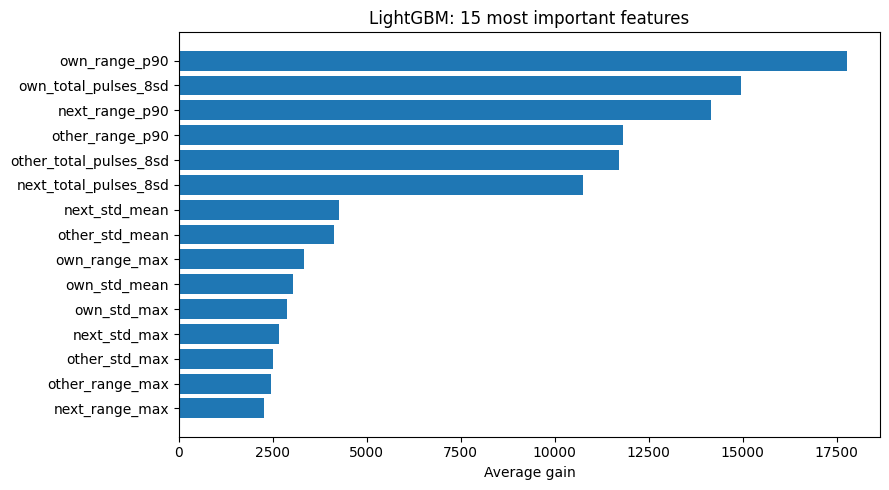

In [11]:
top = np.argsort(importance)[::-1][:15]
plt.figure(figsize=(9, 5))
plt.barh([TAB_NAMES[i] for i in top][::-1], importance[top][::-1], color='tab:blue')
plt.xlabel('Average gain'); plt.title('LightGBM: 15 most important features')
plt.tight_layout(); plt.show()

## 12. Write the Kaggle submission files

One file per experiment (`signal_id,target`, 20,337 rows), using that experiment's ensemble predictions with its own α and cut-off. **Submit first the experiment with the highest "+ phase blending MCC"**; choosing by cross-validation keeps the comparison with published results honest. If you submit others too, report all their scores.

In [12]:
for e in ALL:
    p = phase_blend(pred_kaggle[e], ORDER_K, settings[e]['alpha'])
    sub = pd.DataFrame({'signal_id': meta_k['signal_id'], 'target': (p > settings[e]['threshold']).astype(int)})
    sub.to_csv(f'{OUT_DIR}/submission_{e}.csv', index=False)
    print(f'submission_{e}.csv: {len(sub)} rows, {sub["target"].sum()} predicted PD ({sub["target"].mean():.1%})')

best_e = summary.sort_values('+ phase blending MCC', ascending=False)['Experiment'].iloc[0]
print('\nBest by cross-validation:', best_e)
with open(f'{OUT_DIR}/test3_settings.json', 'w') as f:
    json.dump({'settings': settings, 'best_by_cv': best_e, 'seeds': SEEDS,
               'best_iterations': {e: [int(i) for i in v] for e, v in best_iters.items()}}, f, indent=2)

submission_CNN_7feat.csv: 20337 rows, 1092 predicted PD (5.4%)
submission_CNN_12feat.csv: 20337 rows, 858 predicted PD (4.2%)
submission_LGBM_12feat.csv: 20337 rows, 1041 predicted PD (5.1%)
submission_Blend.csv: 20337 rows, 618 predicted PD (3.0%)

Best by cross-validation: CNN_12feat


## 13. Internal test evaluation (switched off)

Kept for the very end: once the final model is chosen, set `RUN_FINAL_TEST = True` to score it once on the 1,308 internal test signals.

In [13]:
RUN_FINAL_TEST = False
FINAL = best_e

if RUN_FINAL_TEST:
    p = phase_blend(pred_test[FINAL], ORDER, settings[FINAL]['alpha'])[test_idx] > settings[FINAL]['threshold']
    t = y[test_idx]; tn, fp, fn, tp = confusion_matrix(t, p).ravel()
    print(f'{FINAL} internal test MCC: {matthews_corrcoef(t, p):.3f} | PD caught {tp} of {tp + fn} | false alarms {fp} of {fp + tn}')
else:
    print('Internal test evaluation is switched off.')

Internal test evaluation is switched off.
